In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Load file skipping preamble
df = pd.read_csv("glacier_data.csv", skiprows=9, header=None)
df.columns = [
    "glacier_name",
    "glacier_id",
    "date_start",
    "date_start_quality",
    "date_end",
    "date_end_quality",
    "dL",
    "h_min",
    "observer",
]

In [41]:
# =========================
# COLUMN DESCRIPTIONS
# =========================
col_desc = {
    "glacier_name": "Name of the glacier",
    "glacier_id": "Unique glacier identifier (Swiss Glacier Inventory)",
    "date_start": "Start date of observation period",
    "date_start_quality": "Quality flag for start date (x = approximate/uncertain)",
    "date_end": "End date of observation period",
    "date_end_quality": "Quality flag for end date (x = approximate/uncertain)",
    "dL": "Length change over the observation period (meters; negative = retreat)",
    "h_min": "Elevation of glacier tongue (meters above sea level)",
    "observer": "Person or source who reported the observation",
}
print("=" * 70)
print("COLUMN DESCRIPTIONS")
print("=" * 70)
for col, desc in col_desc.items():
    print(f"{col:<22} → {desc}")

COLUMN DESCRIPTIONS
glacier_name           → Name of the glacier
glacier_id             → Unique glacier identifier (Swiss Glacier Inventory)
date_start             → Start date of observation period
date_start_quality     → Quality flag for start date (x = approximate/uncertain)
date_end               → End date of observation period
date_end_quality       → Quality flag for end date (x = approximate/uncertain)
dL                     → Length change over the observation period (meters; negative = retreat)
h_min                  → Elevation of glacier tongue (meters above sea level)
observer               → Person or source who reported the observation


In [42]:
# =========================
# CLEANING and keeping only data > 1950
# =========================
df = df.replace({"": pd.NA, "-": pd.NA})

df["date_start"] = pd.to_datetime(df["date_start"], errors="coerce")
df["date_end"] = pd.to_datetime(df["date_end"], errors="coerce")
df["dL"] = pd.to_numeric(df["dL"], errors="coerce")
df["h_min"] = pd.to_numeric(df["h_min"], errors="coerce")

df["duration_years"] = (df["date_end"] - df["date_start"]).dt.days / 365.25
df["dL_per_year"] = df["dL"] / df["duration_years"]

recent_df = df[df["date_start"] >= "1950-01-01"]

In [43]:
# =========================
# Analysis
# =========================
n_rows = len(df)
n_glaciers = df["glacier_name"].nunique()

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(f"\nRows: {n_rows:,}")
print(f"Glaciers: {n_glaciers:,}")
print(f"Period: {df['date_start'].min().date()} → {df['date_end'].max().date()}")

print("\nMissing values (%):")
print((df.isna().mean() * 100).round(1))

print("\nLength change (dL):")
print(f"  Mean:   {df['dL'].mean():.2f} m")
print(f"  Median: {df['dL'].median():.2f} m")
print(f"  Total:  {df['dL'].sum():.0f} m")

print("\nRate (m/year):")
print(f"  Mean:   {df['dL_per_year'].mean():.2f}")
print(f"  Median: {df['dL_per_year'].median():.2f}")

print("\nRetreat vs advance:")
print(f"  Retreat: {(df['dL'] < 0).mean()*100:.1f}%")
print(f"  Advance: {(df['dL'] > 0).mean()*100:.1f}%")


DATASET SUMMARY

Rows: 10,861
Glaciers: 156
Period: 1847-09-01 → 2024-11-06

Missing values (%):
glacier_name           0.0
glacier_id             0.0
date_start             0.0
date_start_quality    22.4
date_end               0.0
date_end_quality      23.0
dL                     0.0
h_min                 83.9
observer              76.9
duration_years         0.0
dL_per_year            0.0
dtype: float64

Length change (dL):
  Mean:   -14.90 m
  Median: -8.00 m
  Total:  -161835 m

Rate (m/year):
  Mean:   -11.79
  Median: -7.00

Retreat vs advance:
  Retreat: 75.9%
  Advance: 18.4%


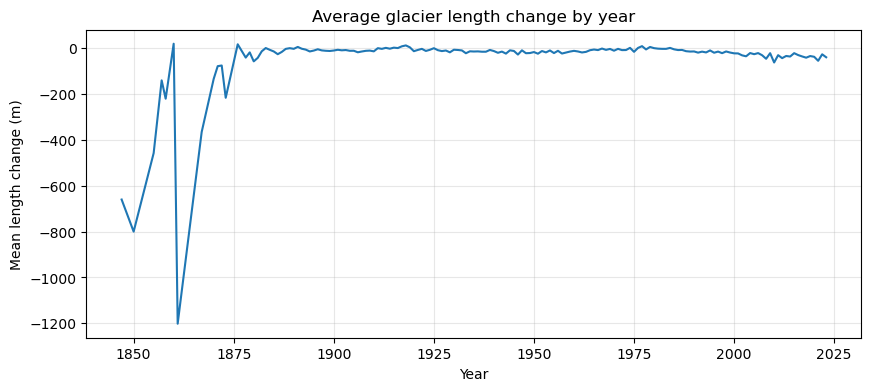

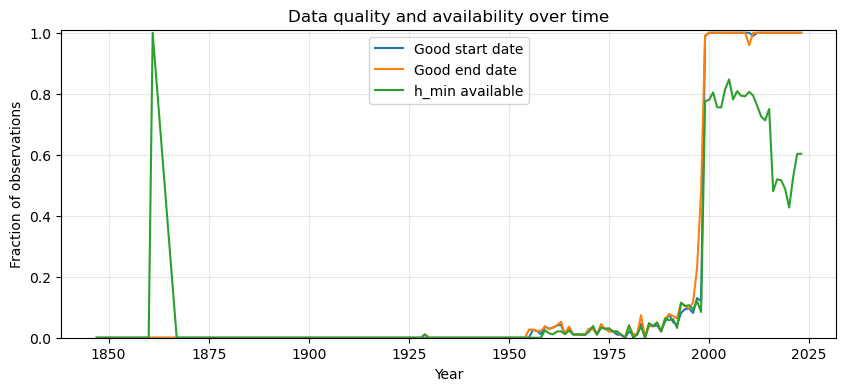

In [44]:
# =========================
# PLOT
# =========================
yearly = df.groupby(df["date_start"].dt.year)["dL"].mean()

plt.figure(figsize=(10, 4))
plt.plot(yearly.index, yearly.values)
plt.xlabel("Year")
plt.ylabel("Mean length change (m)")
plt.title("Average glacier length change by year")
plt.grid(True, alpha=0.3)
plt.show()

df["good_start"] = df["date_start_quality"].isna()
df["good_end"] = df["date_end_quality"].isna()
df["has_h_min"] = df["h_min"].notna()

df["year"] = df["date_start"].dt.year

quality_by_year = df.groupby("year")[["good_start", "good_end", "has_h_min"]].mean()

plt.figure(figsize=(10, 4))

plt.plot(quality_by_year.index, quality_by_year["good_start"], label="Good start date")
plt.plot(quality_by_year.index, quality_by_year["good_end"], label="Good end date")
plt.plot(quality_by_year.index, quality_by_year["has_h_min"], label="h_min available")

plt.xlabel("Year")
plt.ylabel("Fraction of observations")
plt.title("Data quality and availability over time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.01)

plt.show()

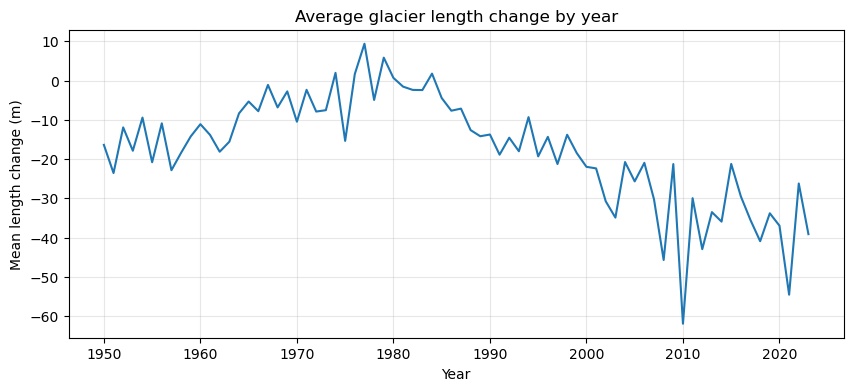

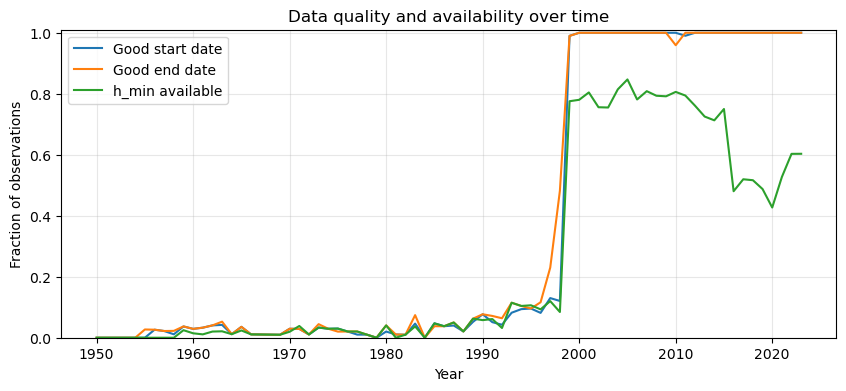

In [45]:
# =========================
# PLOT
# =========================
yearly = recent_df.groupby(df["date_start"].dt.year)["dL"].mean()

plt.figure(figsize=(10, 4))
plt.plot(yearly.index, yearly.values)
plt.xlabel("Year")
plt.ylabel("Mean length change (m)")
plt.title("Average glacier length change by year")
plt.grid(True, alpha=0.3)
plt.show()

recent_df["good_start"] = recent_df["date_start_quality"].isna()
recent_df["good_end"] = recent_df["date_end_quality"].isna()
recent_df["has_h_min"] = recent_df["h_min"].notna()

recent_df["year"] = recent_df["date_start"].dt.year

quality_by_year = recent_df.groupby("year")[["good_start", "good_end", "has_h_min"]].mean()

plt.figure(figsize=(10, 4))

plt.plot(quality_by_year.index, quality_by_year["good_start"], label="Good start date")
plt.plot(quality_by_year.index, quality_by_year["good_end"], label="Good end date")
plt.plot(quality_by_year.index, quality_by_year["has_h_min"], label="h_min available")

plt.xlabel("Year")
plt.ylabel("Fraction of observations")
plt.title("Data quality and availability over time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.01)

plt.show()